1. Country name: Name of the country.
2. Regional indicator: Region to which the country belongs.
3. Ladder score: The happiness score for each country, based on responses to the Cantril Ladder question that asks respondents to think of a ladder, with the best possible life for them being a 10, and the worst possible life being a 0.
4. Upper whisker: Upper bound of the happiness score.
5. Lower whisker: Lower bound of the happiness score.
6. Log GDP per capita: The natural logarithm of the country's GDP per capita, adjusted for purchasing power parity (PPP) to account for differences in the cost of living between countries.
7. Social support: The national average of binary responses(either 0 or 1 representing No/Yes) to the question about having relatives or friends to count on in times of trouble.
8. Healthy life expectancy: The average number of years a newborn infant would live in good health, based on mortality rates and life expectancy at different ages.
9. Freedom to make life choices: The national average of responses to the question about satisfaction with freedom to choose what to do with one's life.
10. Generosity: The residual of regressing the national average of responses to the question about donating money to charity on GDP per capita.
11. Perceptions of corruption: The national average of survey responses to questions about the perceived extent of corruption in the government and businesses.
12. Dystopia + residual: Dystopia is an imaginary country with the world’s least-happy people, used as a benchmark for comparison. The dystopia + residual score is a combination of the Dystopia score and the unexplained residual for each country, ensuring that the combined score is always positive. Each of these factors contributes to the overall happiness score, but the Dystopia + residual value is a benchmark that ensures no country has a lower score than the hypothetical Dystopia.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
df = pd.read_csv(r"C:\Users\HP\Downloads\World-happiness-report-2024.csv")
df

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298
...,...,...,...,...,...,...,...,...,...,...,...,...
138,Congo (Kinshasa),Sub-Saharan Africa,3.295,3.462,3.128,0.534,0.665,0.262,0.473,0.189,0.072,1.102
139,Sierra Leone,Sub-Saharan Africa,3.245,3.366,3.124,0.654,0.566,0.253,0.469,0.181,0.053,1.068
140,Lesotho,Sub-Saharan Africa,3.186,3.469,2.904,0.771,0.851,0.000,0.523,0.082,0.085,0.875
141,Lebanon,Middle East and North Africa,2.707,2.797,2.616,1.377,0.577,0.556,0.173,0.068,0.029,-0.073


# Data Info (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [5]:
df.shape

(143, 12)

In [6]:
df.describe()

,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [7]:
df.describe(include="object")

,Country name,Regional indicator
count,143,143
unique,143,10
top,Finland,Sub-Saharan Africa
freq,1,35


In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64

In [10]:
df.isnull().sum()/df.shape[0]*100

Country name                    0.000000
Regional indicator              0.000000
Ladder score                    0.000000
upperwhisker                    0.000000
lowerwhisker                    0.000000
Log GDP per capita              2.097902
Social support                  2.097902
Healthy life expectancy         2.097902
Freedom to make life choices    2.097902
Generosity                      2.097902
Perceptions of corruption       2.097902
Dystopia + residual             2.097902
dtype: float64

<Axes: >

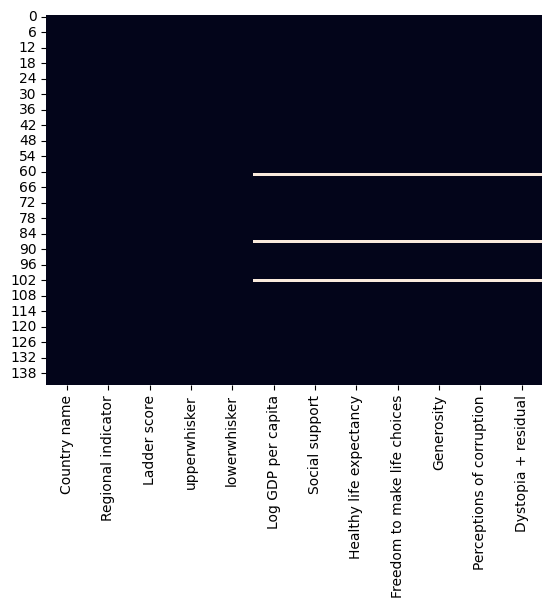

In [11]:
sns.heatmap(df.isnull(),cbar=False)

array([[<Axes: title={'center': 'Ladder score'}>,
        <Axes: title={'center': 'upperwhisker'}>,
        <Axes: title={'center': 'lowerwhisker'}>],
       [<Axes: title={'center': 'Log GDP per capita'}>,
        <Axes: title={'center': 'Social support'}>,
        <Axes: title={'center': 'Healthy life expectancy'}>],
       [<Axes: title={'center': 'Freedom to make life choices'}>,
        <Axes: title={'center': 'Generosity'}>,
        <Axes: title={'center': 'Perceptions of corruption'}>],
       [<Axes: title={'center': 'Dystopia + residual'}>, <Axes: >,
        <Axes: >]], dtype=object)

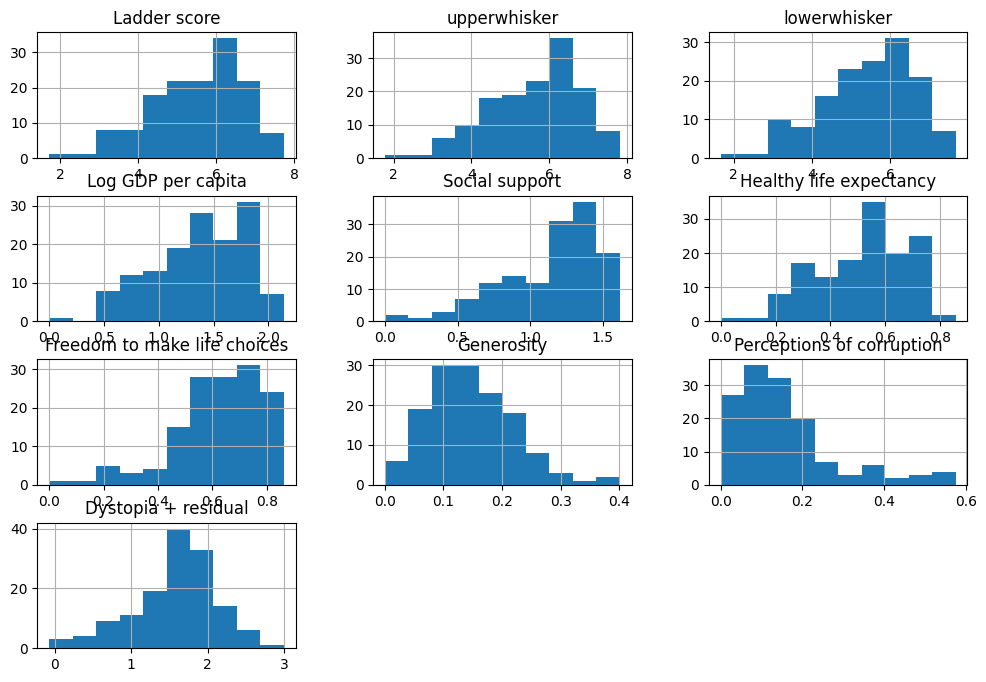

In [12]:
df.hist(figsize=(12,8))

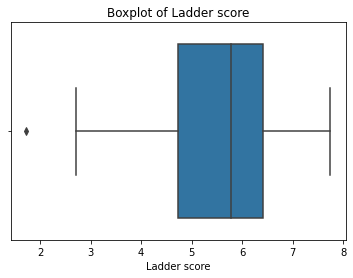

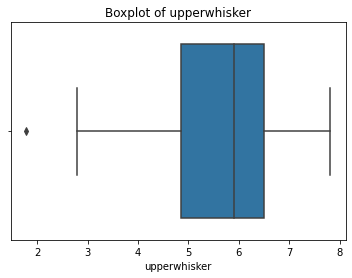

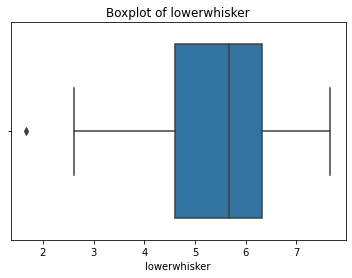

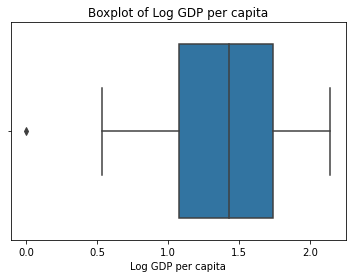

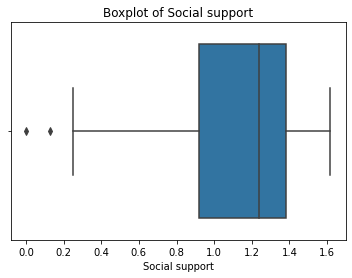

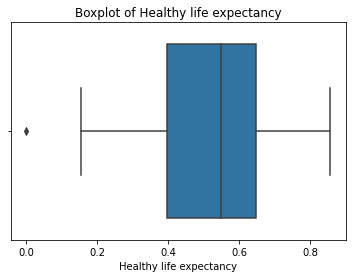

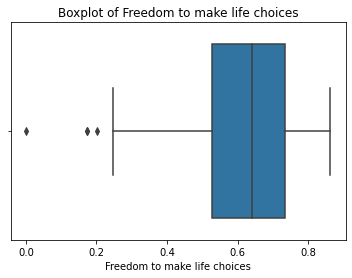

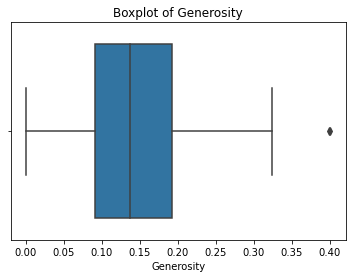

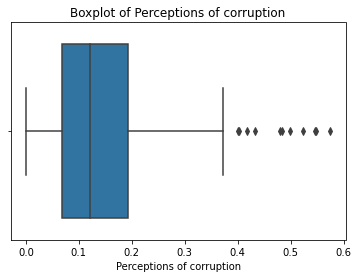

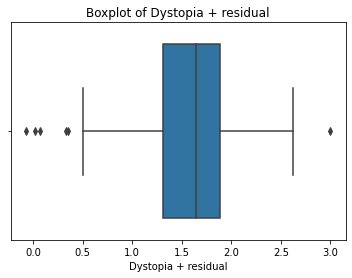

In [14]:
for col in df.select_dtypes(include="number"):
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [15]:
df.skew(numeric_only=True)

Ladder score                   -0.521820
upperwhisker                   -0.547456
lowerwhisker                   -0.499001
Log GDP per capita             -0.507127
Social support                 -0.992283
Healthy life expectancy        -0.546061
Freedom to make life choices   -1.018833
Generosity                      0.663054
Perceptions of corruption       1.524926
Dystopia + residual            -0.601796
dtype: float64

# Handling Missing Values
Log GDP per capita             
Social support                  
Healthy life expectancy         
Freedom to make life choices    
Generosity                      
Perceptions of corruption      
Dystopia + residual

In [29]:
df.dropna(inplace=True)

In [30]:
df.isnull().sum()

Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Dystopia + residual             0
dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  140 non-null    object 
 1   Regional indicator            140 non-null    object 
 2   Ladder score                  140 non-null    float64
 3   upperwhisker                  140 non-null    float64
 4   lowerwhisker                  140 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 14.2+ KB


# Replace and change data types
change data type of Regional indicator

In [32]:
df["Regional indicator"] = df["Regional indicator"].astype("category")

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Country name                  140 non-null    object  
 1   Regional indicator            140 non-null    category
 2   Ladder score                  140 non-null    float64 
 3   upperwhisker                  140 non-null    float64 
 4   lowerwhisker                  140 non-null    float64 
 5   Log GDP per capita            140 non-null    float64 
 6   Social support                140 non-null    float64 
 7   Healthy life expectancy       140 non-null    float64 
 8   Freedom to make life choices  140 non-null    float64 
 9   Generosity                    140 non-null    float64 
 10  Perceptions of corruption     140 non-null    float64 
 11  Dystopia + residual           140 non-null    float64 
dtypes: category(1), float64(10), object(1)
memory usage: 13

In [34]:
X = df.drop(columns=["Country name","Ladder score","upperwhisker","lowerwhisker","Dystopia + residual"])
y = df["Ladder score"]
X.columns

Index(['Regional indicator', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

# Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)
df.shape,X_train.shape,X_test.shape,y_train.shape,y_test.shape

((140, 12), (105, 7), (35, 7), (105,), (35,))

In [36]:
#KFold CV
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
#Stratified KFold CV
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Outlier handling
removing outliers will remove countries and will make size small.

# Encoding
One Hot Encoding of Regional indicator

In [38]:
X_train = pd.get_dummies(X_train, columns=["Regional indicator"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Regional indicator"], drop_first=True)
X_train,X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [39]:
X_train.columns

Index(['Log GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption',
       'Regional indicator_Commonwealth of Independent States',
       'Regional indicator_East Asia',
       'Regional indicator_Latin America and Caribbean',
       'Regional indicator_Middle East and North Africa',
       'Regional indicator_North America and ANZ',
       'Regional indicator_South Asia', 'Regional indicator_Southeast Asia',
       'Regional indicator_Sub-Saharan Africa',
       'Regional indicator_Western Europe'],
      dtype='object')

# Feature Engineering-
no need to extract new features

# Function transformation-
yeo-johnson for freedom, corruption and social support

In [43]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 45 to 105
Data columns (total 15 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Log GDP per capita                                     105 non-null    float64
 1   Social support                                         105 non-null    float64
 2   Healthy life expectancy                                105 non-null    float64
 3   Freedom to make life choices                           105 non-null    float64
 4   Generosity                                             105 non-null    float64
 5   Perceptions of corruption                              105 non-null    float64
 6   Regional indicator_Commonwealth of Independent States  105 non-null    bool   
 7   Regional indicator_East Asia                           105 non-null    bool   
 8   Regional indicator_Latin America and Caribbean        

In [41]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 111 to 51
Data columns (total 15 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Log GDP per capita                                     35 non-null     float64
 1   Social support                                         35 non-null     float64
 2   Healthy life expectancy                                35 non-null     float64
 3   Freedom to make life choices                           35 non-null     float64
 4   Generosity                                             35 non-null     float64
 5   Perceptions of corruption                              35 non-null     float64
 6   Regional indicator_Commonwealth of Independent States  35 non-null     bool   
 7   Regional indicator_East Asia                           35 non-null     bool   
 8   Regional indicator_Latin America and Caribbean         

In [44]:
X_train.skew()

Log GDP per capita                                      -0.643402
Social support                                          -1.139098
Healthy life expectancy                                 -0.663939
Freedom to make life choices                            -1.038274
Generosity                                               0.523487
Perceptions of corruption                                1.519368
Regional indicator_Commonwealth of Independent States    3.524954
Regional indicator_East Asia                             4.310352
Regional indicator_Latin America and Caribbean           2.317585
Regional indicator_Middle East and North Africa          2.797894
Regional indicator_North America and ANZ                 5.741807
Regional indicator_South Asia                            4.310352
Regional indicator_Southeast Asia                        3.241405
Regional indicator_Sub-Saharan Africa                    1.378337
Regional indicator_Western Europe                        1.862373
dtype: flo

In [49]:
from sklearn.preprocessing import PowerTransformer
skewed_cols = [
    "Log GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]
pt_YJ = PowerTransformer(method="yeo-johnson")
# Fit + transform training data
X_train[skewed_cols] = pt_YJ.fit_transform(
    X_train[skewed_cols]
)
# Transform test data
X_test[skewed_cols] = pt_YJ.transform(
    X_test[skewed_cols]
)

In [52]:
X_train[skewed_cols].skew()

Log GDP per capita             -0.138160
Social support                 -0.267896
Healthy life expectancy        -0.108969
Freedom to make life choices   -0.098216
Generosity                      0.003765
Perceptions of corruption       0.156902
dtype: float64

In [53]:
X_test[skewed_cols].skew()

Log GDP per capita              0.215363
Social support                 -0.144354
Healthy life expectancy         0.161781
Freedom to make life choices   -0.323511
Generosity                      0.274736
Perceptions of corruption       0.336664
dtype: float64

# Feature Scaling
not required as data is already scaled

# Feature Selection

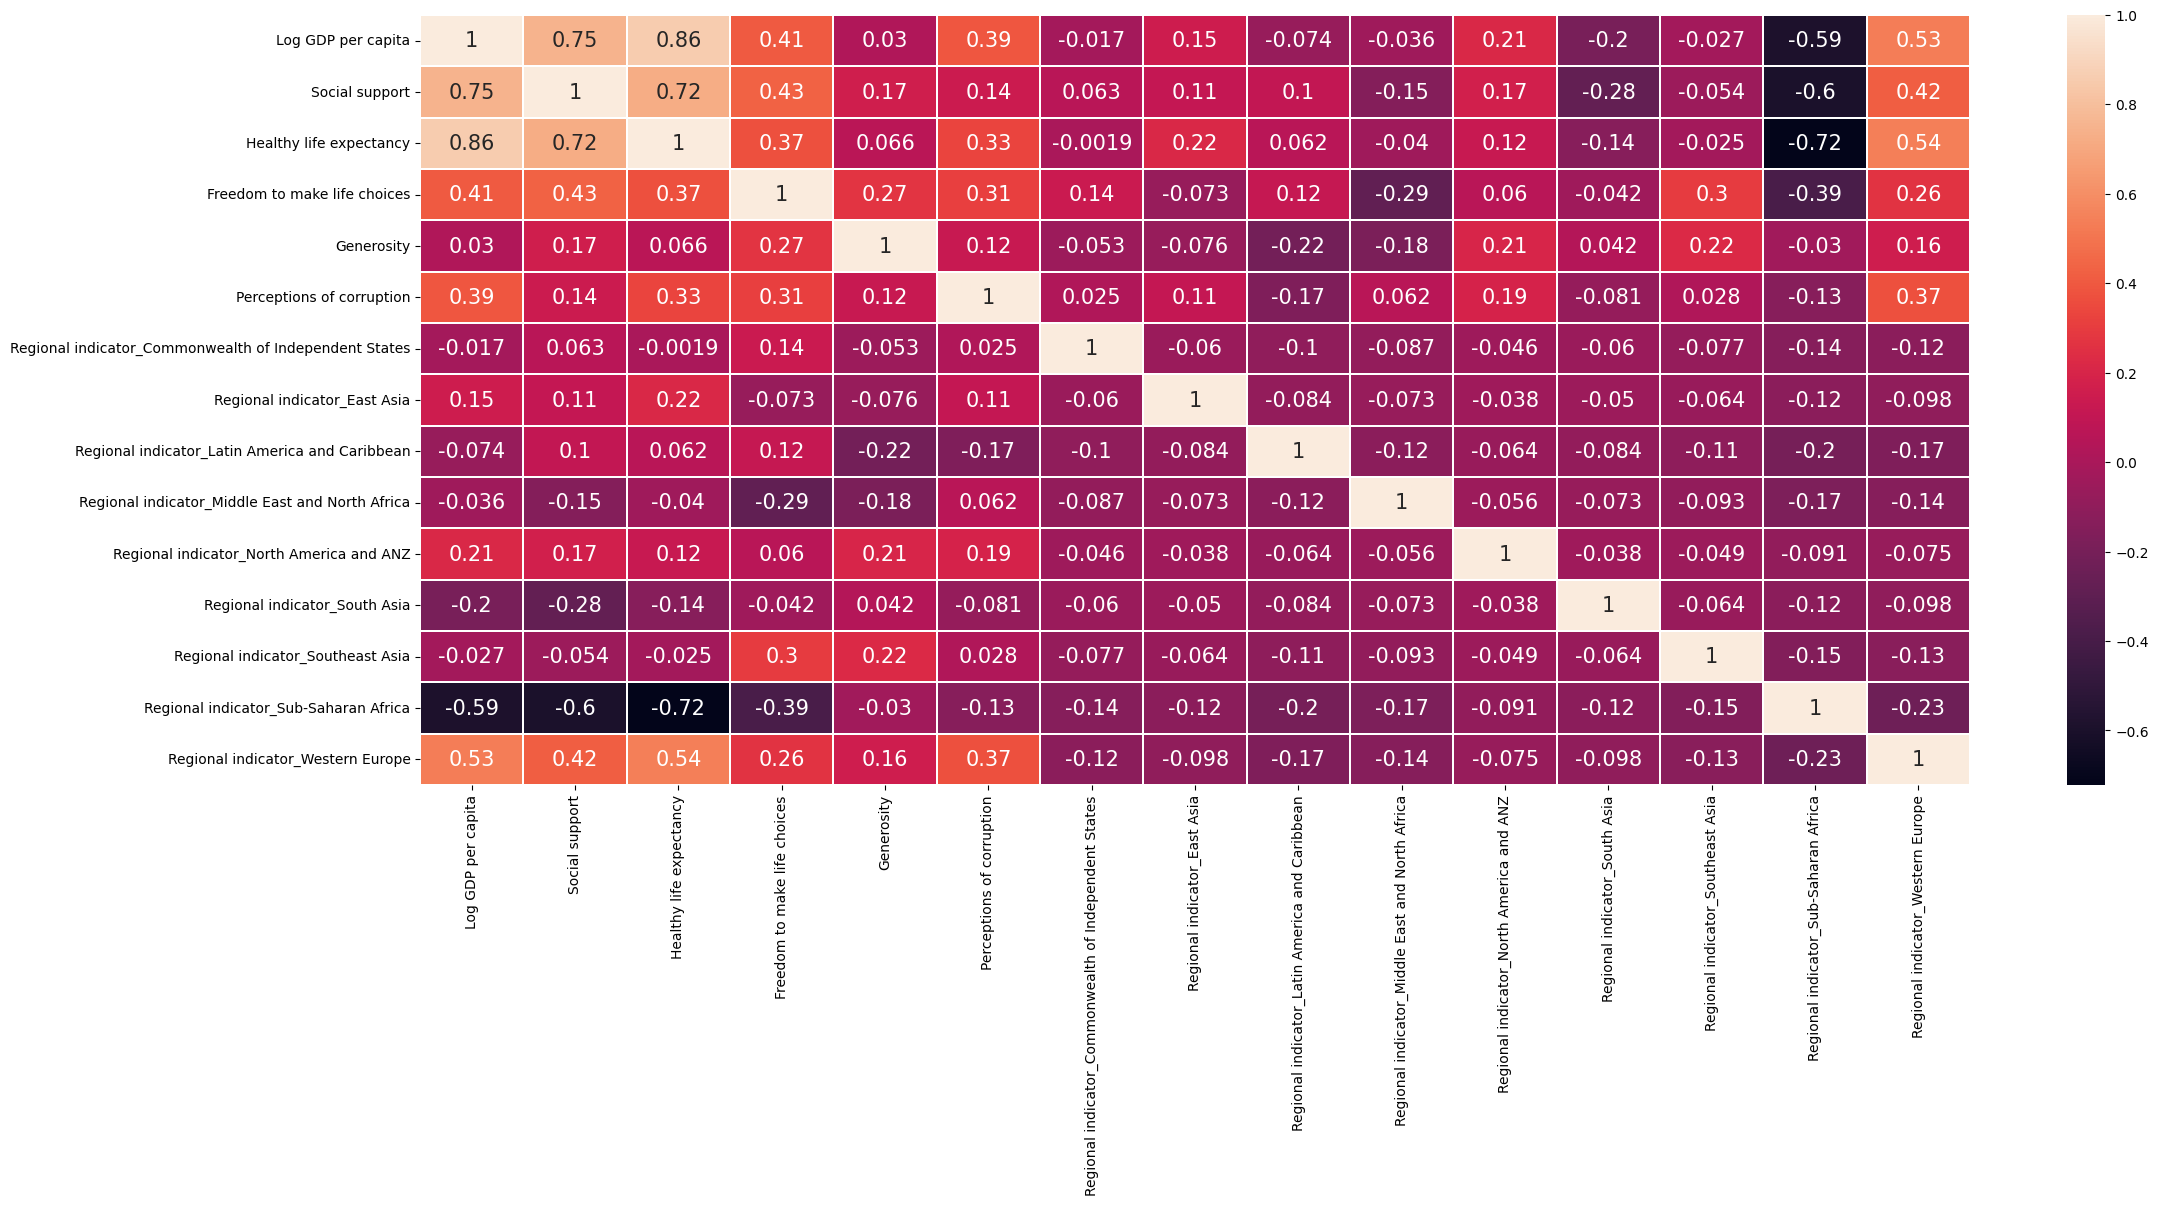

In [54]:
corr = X_train.corr()
fig, ax = plt.subplots(figsize=(25, 10))
sns.heatmap(corr,annot=True,annot_kws={'size': 15},linewidths=0.3)
plt.show()

In [55]:
#Correlation with target variable- advice to remove Age_Group
corr_values = X_train.corrwith(y_train)
print(corr_values)

Log GDP per capita                                       0.788694
Social support                                           0.815223
Healthy life expectancy                                  0.756404
Freedom to make life choices                             0.606883
Generosity                                               0.198944
Perceptions of corruption                                0.362972
Regional indicator_Commonwealth of Independent States    0.017552
Regional indicator_East Asia                             0.068064
Regional indicator_Latin America and Caribbean           0.189943
Regional indicator_Middle East and North Africa         -0.166459
Regional indicator_North America and ANZ                 0.196711
Regional indicator_South Asia                           -0.346550
Regional indicator_Southeast Asia                       -0.001012
Regional indicator_Sub-Saharan Africa                   -0.563291
Regional indicator_Western Europe                        0.491725
dtype: flo

In [56]:
#wrapper method
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [57]:
#forward selection- advice to keep the following list
sfs_f = SequentialFeatureSelector(lr,n_features_to_select=6,direction="forward")
sfs_f.fit(X_train,y_train)

forward_selected = list(sfs_f.get_feature_names_out())
forward_selected

['Log GDP per capita',
 'Social support',
 'Freedom to make life choices',
 'Regional indicator_Latin America and Caribbean',
 'Regional indicator_South Asia',
 'Regional indicator_Western Europe']

In [58]:
#backward selection- advice to keep the following list
sfs_b = SequentialFeatureSelector(lr,n_features_to_select=6,direction="backward")
sfs_b.fit(X_train,y_train)

backward_selected = list(sfs_b.get_feature_names_out())
backward_selected

['Log GDP per capita',
 'Social support',
 'Freedom to make life choices',
 'Regional indicator_Latin America and Caribbean',
 'Regional indicator_South Asia',
 'Regional indicator_Western Europe']

In [59]:
#Embedded Method- lasso
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train,y_train)
results = pd.DataFrame({"Feature":X_train.columns,"Coefficient":lasso.coef_})
results

,Feature,Coefficient
0,Log GDP per capita,0.344743
1,Social support,0.389397
2,Healthy life expectancy,0.112670
3,Freedom to make life choices,0.261824
4,Generosity,0.098202
5,Perceptions of corruption,0.098487
6,Regional indicator_Commonwealth of Independent...,-0.000000
7,Regional indicator_East Asia,-0.000000
8,Regional indicator_Latin America and Caribbean,0.517212
9,Regional indicator_Middle East and North Africa,-0.000000


In [60]:
#Random Forest Regressor-
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
imp = pd.DataFrame({"Feature":X_train.columns,"Importance":rf.feature_importances_})
imp

,Feature,Importance
0,Log GDP per capita,0.174388
1,Social support,0.461475
2,Healthy life expectancy,0.195025
3,Freedom to make life choices,0.093873
4,Generosity,0.015957
5,Perceptions of corruption,0.027338
6,Regional indicator_Commonwealth of Independent...,0.000409
7,Regional indicator_East Asia,0.000560
8,Regional indicator_Latin America and Caribbean,0.006887
9,Regional indicator_Middle East and North Africa,0.002859


# Baseline Model
using DummyRegressor

In [62]:
from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)
print(f"Baseline R²: {baseline_score:.3f}")

Baseline R²: -0.006


In [63]:
from sklearn.metrics import mean_squared_error
import numpy as np
y_pred = baseline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Baseline RMSE: {rmse:.3f}")

Baseline RMSE: 1.204


# Cross_Validation
using RandomForestRegressor

In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)
print(f"Cross-Val R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Val R²: 0.7672 ± 0.0613


In [65]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)
print(f"Cross-Val R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-Val R²: 0.7499 ± 0.0899


# Model Building
1. Regression-
Linear Regression- one linear input variable
Multiple Regression- mutiple linear input variables
Polynomial Regression- one or multiple non-linear input variables
2. Decision Tree
3. Random Forest
4. K-nearest neighbours

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

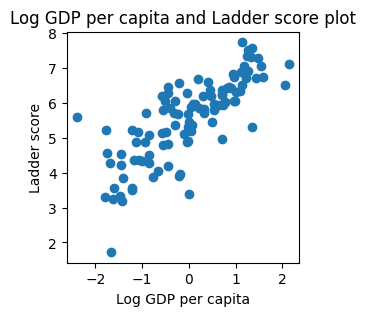

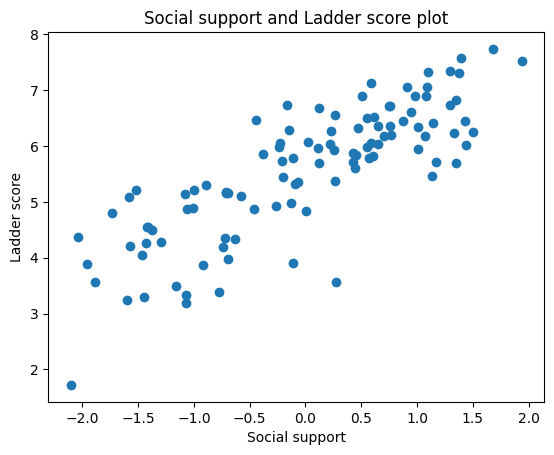

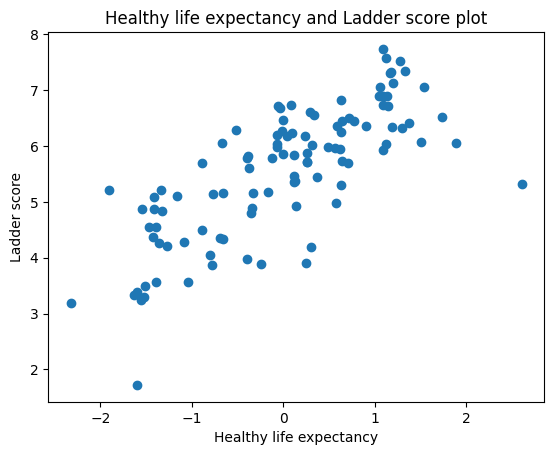

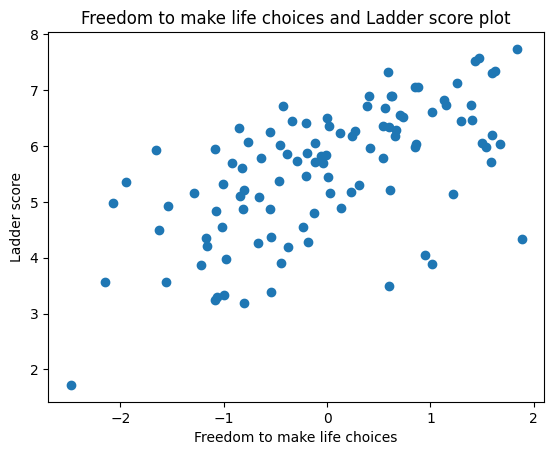

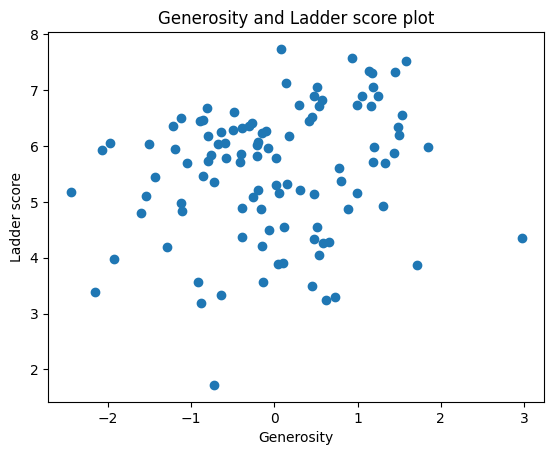

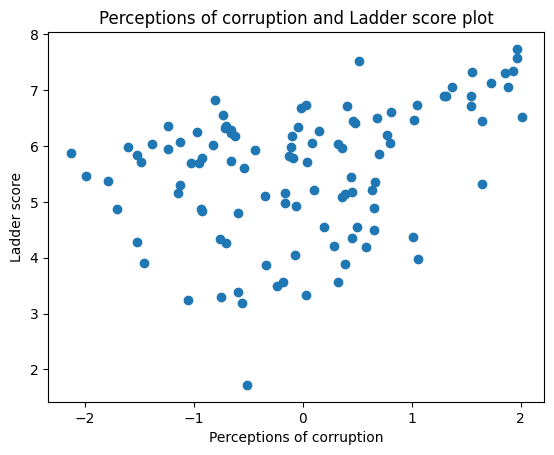

In [69]:
plt.figure(figsize=(3,3))
for col in X_train.select_dtypes(include=float):
    plt.scatter(X_train[col],y_train)
    plt.title(f"{col} and Ladder score plot")
    plt.xlabel(col)
    plt.ylabel("Ladder score")
    plt.show()

In [50]:
#inferring from the scatterplot- multiple regression will be used

In [70]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [71]:
lr.score(X_train,y_train)

0.8691467982583476

In [72]:
lr.score(X_test,y_test)

0.7798304798937731

In [73]:
lr.coef_

array([ 0.34192012,  0.30496388,  0.06589222,  0.27594195,  0.11610897,
        0.10831477, -0.21324675, -0.12603376,  0.48101654, -0.23521576,
        0.10118178, -1.12640147, -0.40498113, -0.30487282,  0.11581485])

In [74]:
lr.intercept_

5.666689256258307

In [80]:
#checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm
X = X_train.copy()
X_const = sm.add_constant(X)
vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

vif

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

# Check Regression Cost
1. Mean Absolute Error
2. Mean Squared Error
3. Root Mean Squared Error
4. R2
5. Adjusted R2

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, lr.predict(X_test))

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, lr.predict(X_test))

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R2 Score
r2 = r2_score(y_test, lr.predict(X_test))

# 5. Adjusted R2
n = len(y_test)              # number of observations
k = X_test.shape[1]          # number of predictors (features)

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 0.4544
MSE: 0.3172
RMSE: 0.5632
R2: 0.7798
Adjusted R2: 0.6060


# Decision Tree Model

In [82]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [83]:
dt.score(X_train,y_train)

0.8643048118699141

In [84]:
dt.score(X_test,y_test)

0.646606413186612

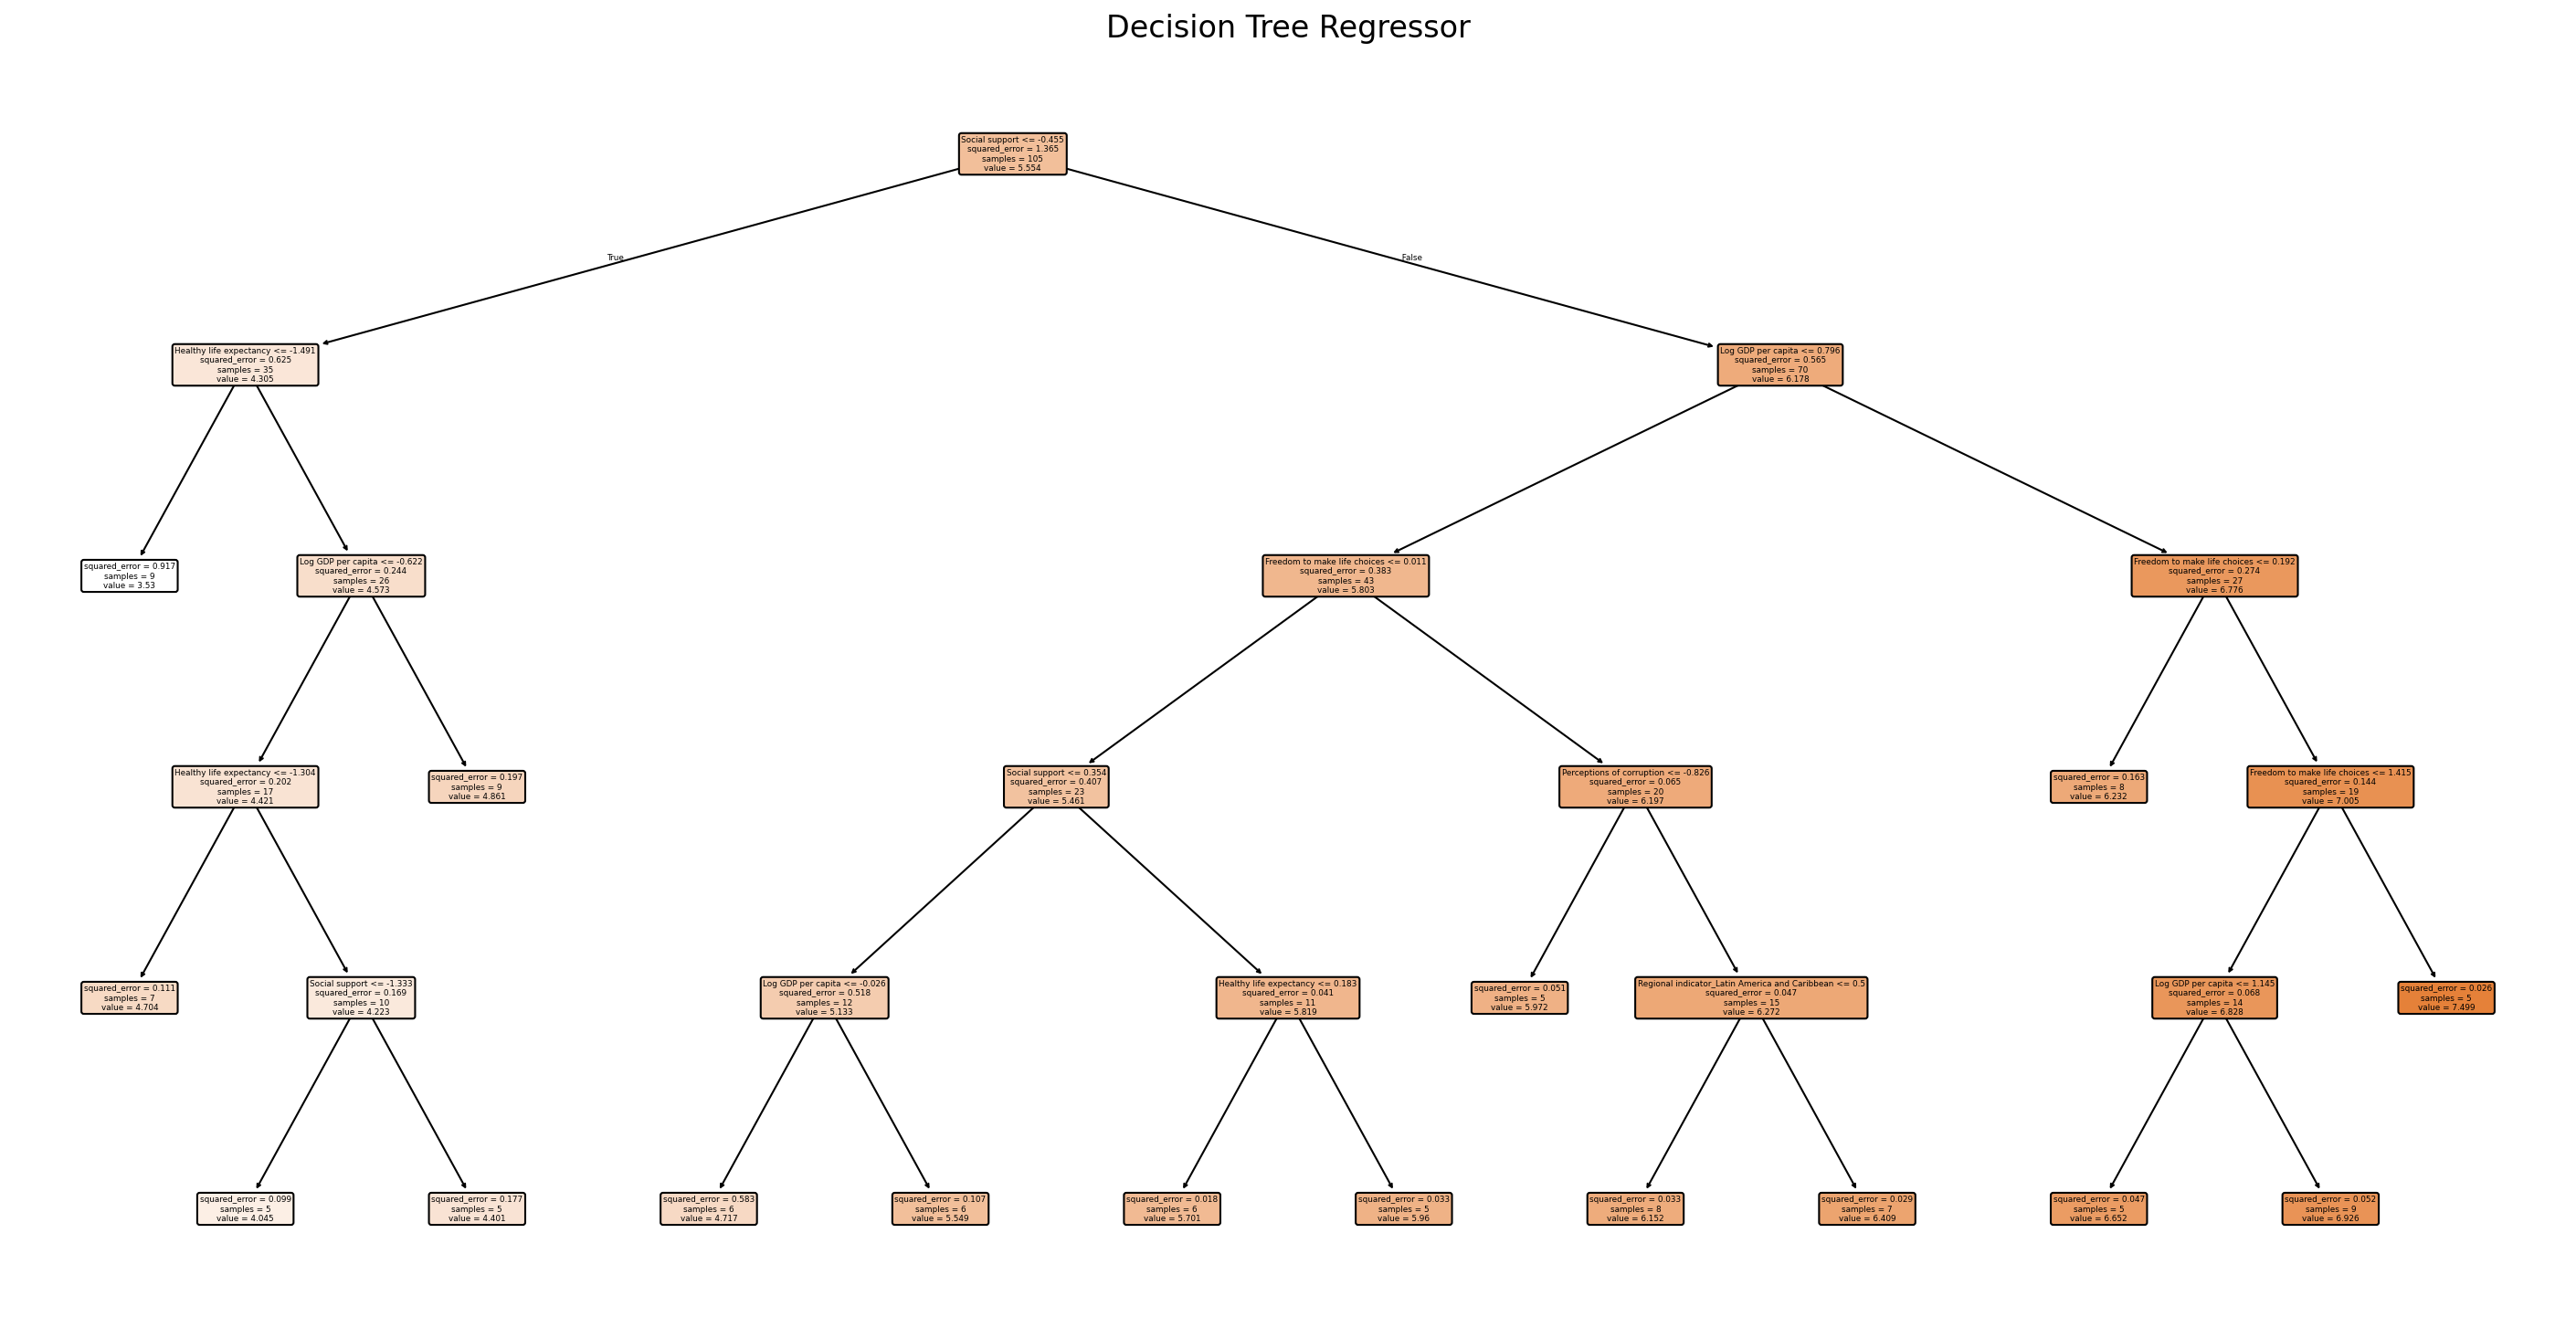

In [85]:
from sklearn.tree import plot_tree
plt.figure(figsize=(24,12),dpi=150)
plot_tree(dt,feature_names=X_train.columns,filled=True,rounded=True)
plt.title("Decision Tree Regressor",fontsize=16)
plt.show()

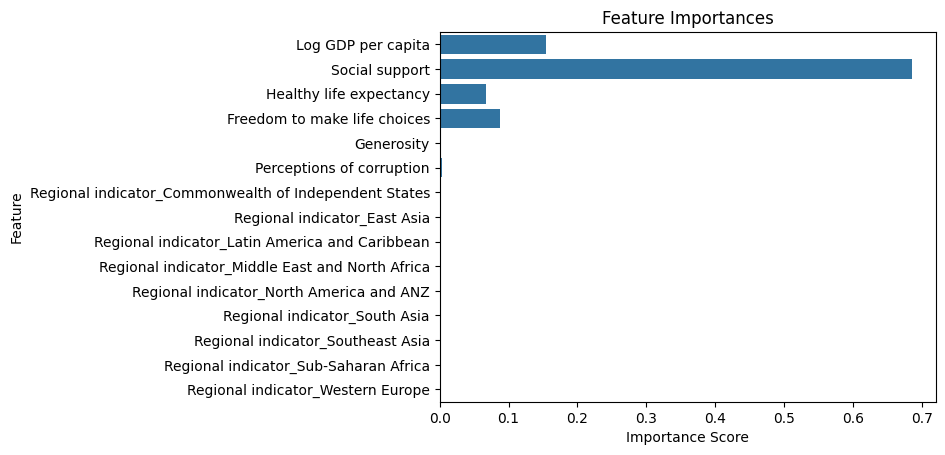

In [86]:
importances = dt.feature_importances_
sns.barplot(x=importances,y=X_train.columns)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [87]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, dt.predict(X_test))

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, dt.predict(X_test))

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R2 Score
r2 = r2_score(y_test, dt.predict(X_test))

# 5. Adjusted R2
n = len(y_test)              # number of observations
k = X_test.shape[1]          # number of predictors (features)

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 0.5333
MSE: 0.5091
RMSE: 0.7135
R2: 0.6466
Adjusted R2: 0.3676


# Random Forest Algorithm

In [88]:
#criteria- squared error
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [89]:
rf.score(X_train,y_train)

0.966377792243972

In [90]:
rf.score(X_test,y_test)

0.7381644044002609

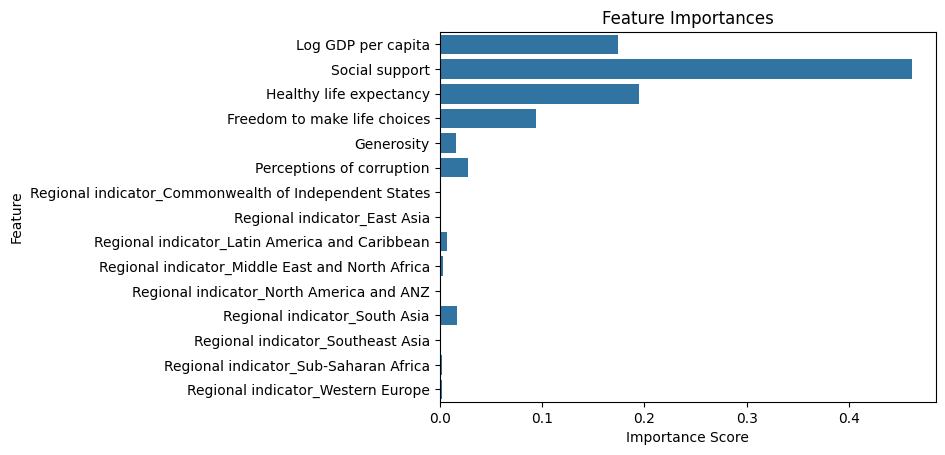

In [91]:
importances = rf.feature_importances_
sns.barplot(x=importances,y=X_train.columns)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, rf.predict(X_test))

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, rf.predict(X_test))

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R2 Score
r2 = r2_score(y_test, rf.predict(X_test))

# 5. Adjusted R2
n = len(y_test)              # number of observations
k = X_test.shape[1]          # number of predictors (features)

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 0.4606
MSE: 0.3772
RMSE: 0.6142
R2: 0.7382
Adjusted R2: 0.5315


In [93]:
#criteria- absolute error
rf = RandomForestRegressor(criterion="absolute_error",random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(criterion='absolute_error', random_state=42)

In [94]:
rf.score(X_train,y_train)

0.9670739940536258

In [95]:
rf.score(X_test,y_test)

0.7394441457607166

In [96]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, rf.predict(X_test))

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, rf.predict(X_test))

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R2 Score
r2 = r2_score(y_test, rf.predict(X_test))

# 5. Adjusted R2
n = len(y_test)              # number of observations
k = X_test.shape[1]          # number of predictors (features)

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 0.4548
MSE: 0.3754
RMSE: 0.6127
R2: 0.7394
Adjusted R2: 0.5337


In [97]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42
)
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=200, random_state=42)

In [98]:
rf.score(X_train,y_train)

0.9097794303128778

In [99]:
rf.score(X_test,y_test)

0.7393506733024728

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, rf.predict(X_test))

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, rf.predict(X_test))

# 3. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# 4. R2 Score
r2 = r2_score(y_test, rf.predict(X_test))

# 5. Adjusted R2
n = len(y_test)              # number of observations
k = X_test.shape[1]          # number of predictors (features)

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE: 0.4725
MSE: 0.3755
RMSE: 0.6128
R2: 0.7394
Adjusted R2: 0.5336


# K-Nearest Neighbours
1. Euclidean Distance- continuous and normal data, features on same scale, after normalisation
2. Manhattan Distance- grid-like data, movement only along axes, high-dimensional data

In [101]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()
knn.fit(X_train,y_train)

KNeighborsRegressor()

In [102]:
knn.score(X_train,y_train)

0.8087519027236096

In [103]:
knn.score(X_test,y_test)

0.7100041279348507

In [104]:
knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train,y_train)

KNeighborsRegressor(n_neighbors=6)

In [105]:
knn.score(X_train,y_train)

0.7965333249731867

In [106]:
knn.score(X_test,y_test)

0.7220409596796159

# Bias-Variance Tradeoff
1. Bias- error due to oversimplification, results in underfitting (might be due to linear fit)
2. Variance- error due to over-complex model, results in overfitting (might be due to polynomial fit of degree 8)
3. Tradeoff- balance between bias and variance (like polynomial fit of degree 2)

# Cross-Validation

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
model = LinearRegression()
cv_scores = cross_val_score(model,X_train,y_train,cv=5,scoring="r2")
print("Linear Regression CV R2:",cv_scores)
print(f"Mean R2: {cv_scores.mean():.4f}")

Linear Regression CV R2: [0.81326146 0.68325229 0.81546993 0.72349212 0.8736911 ]
Mean R2: 0.7818


In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
model = LinearRegression()
cv_scores = cross_val_score(model,X_test,y_test,cv=5,scoring="r2")
print("Linear Regression CV R2:",cv_scores)
print(f"Mean R2: {cv_scores.mean():.4f}")

Linear Regression CV R2: [ 0.8578742  -0.1963716   0.36417804  0.62947717  0.29539498]
Mean R2: 0.3901


In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
model = LinearRegression()
cv_scores = cross_val_score(model,X_train,y_train,cv=kf,scoring="r2")
print("Linear Regression CV R2:",cv_scores)
print(f"Mean R2: {cv_scores.mean():.4f}")

Linear Regression CV R2: [0.86851238 0.765469   0.61475772 0.79883546 0.67477951]
Mean R2: 0.7445


In [110]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
model = LinearRegression()
cv_scores = cross_val_score(model,X_test,y_test,cv=kf,scoring="r2")
print("Linear Regression CV R2:",cv_scores)
print(f"Mean R2: {cv_scores.mean():.4f}")

Linear Regression CV R2: [ 0.59580491  0.28523178 -0.98558129  0.5187602   0.36868339]
Mean R2: 0.1566
